##Importing Libraries


In [38]:
%pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix



##Loading the dataset into the collab file


In [40]:
df = pd.read_csv('data/synthetic_health.csv')

##Getting to know the data


###Looking at first 5 entries


In [41]:
#.head() -> Gives first 5 data points
df.head()

,age,systolic_bp,cholesterol,max_heart_rate,bmi,sex,chest_pain,smoker,diabetes,exercise_angina,risk
0,68.0,137,252.0,140,NaN,Male,non-anginal,NaN,No,No,1
1,58.0,128,187.0,186,39.0,Female,typical,Yes,Yes,Yes,1
2,44.0,131,199.0,181,37.0,Male,typical,Yes,No,Yes,0
3,72.0,115,247.0,97,35.8,Male,asymptomatic,No,Yes,Yes,1
4,37.0,139,231.0,123,32.4,Female,atypical,No,No,No,0


###Getting to know the dimensions of dataset

In [42]:
#.shape -> Gives dimensions of the dataset
df.shape

(400, 11)

###Looking at column names

In [43]:
df.columns #.columns -> gives columns

Index(['age', 'systolic_bp', 'cholesterol', 'max_heart_rate', 'bmi', 'sex',
       'chest_pain', 'smoker', 'diabetes', 'exercise_angina', 'risk'],
      dtype='str')

###Knowing datatypes of columns is really important

In [44]:
df.info() #.info() -> Gives datatypes of each column

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              380 non-null    float64
 1   systolic_bp      400 non-null    int64  
 2   cholesterol      380 non-null    float64
 3   max_heart_rate   400 non-null    int64  
 4   bmi              380 non-null    float64
 5   sex              380 non-null    str    
 6   chest_pain       400 non-null    str    
 7   smoker           380 non-null    str    
 8   diabetes         400 non-null    str    
 9   exercise_angina  400 non-null    str    
 10  risk             400 non-null    int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 34.5 KB


### Define X and y

In [45]:
X = df.drop('risk', axis=1)
y = df['risk']

### Missing value check

In [46]:
df.isnull().sum() #.isnull().sum() -> Gives missing values in each column

age                20
systolic_bp         0
cholesterol        20
max_heart_rate      0
bmi                20
sex                20
chest_pain          0
smoker             20
diabetes            0
exercise_angina     0
risk                0
dtype: int64

###Segregating columns into categorical and numerical

In [47]:
categorical_features = X.select_dtypes(include=['object']).columns #.select_dtypes(include=['object']) -> Gives categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns #.select_dtypes(include=['int64', 'float64']) -> Gives numerical columns

/var/folders/8h/mcpbs1yj49z4dbn9yh70473c0000gn/T/ipykernel_18909/3711673540.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns #.select_dtypes(include=['object']) -> Gives categorical columns


In [48]:
print(categorical_features)
print(numerical_features)

Index(['sex', 'chest_pain', 'smoker', 'diabetes', 'exercise_angina'], dtype='str')
Index(['age', 'systolic_bp', 'cholesterol', 'max_heart_rate', 'bmi'], dtype='str')


##Data preprocessing

###Looking for outliers

In [49]:
outlier_summary = {}
for col in numerical_features:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
  outlier_summary[col] = outliers
outlier_summary

{'age': 0, 'systolic_bp': 0, 'cholesterol': 0, 'max_heart_rate': 0, 'bmi': 0}

### Filling numerical cols with median and categorial with mode wherever data is missing

In [50]:
for col in numerical_features:
    df[col] = df[col].fillna(df[col].median()) #.fillna() -> Fills missing values with median

In [51]:
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0]) #.mode()[0] -> Fills missing values with mode

In [52]:
df.isnull().sum()

age                0
systolic_bp        0
cholesterol        0
max_heart_rate     0
bmi                0
sex                0
chest_pain         0
smoker             0
diabetes           0
exercise_angina    0
risk               0
dtype: int64

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y) #.stratify=y -> Stratifies the data based on y

In [54]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [55]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [56]:
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [57]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [58]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [59]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [60]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.925


In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.71      0.80        17
           1       0.93      0.98      0.95        63

    accuracy                           0.93        80
   macro avg       0.92      0.85      0.88        80
weighted avg       0.92      0.93      0.92        80



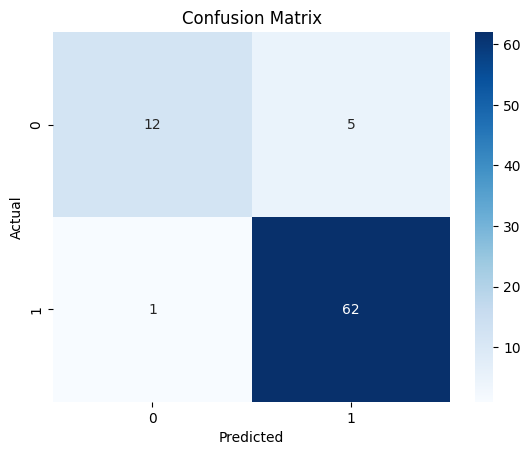

In [62]:


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

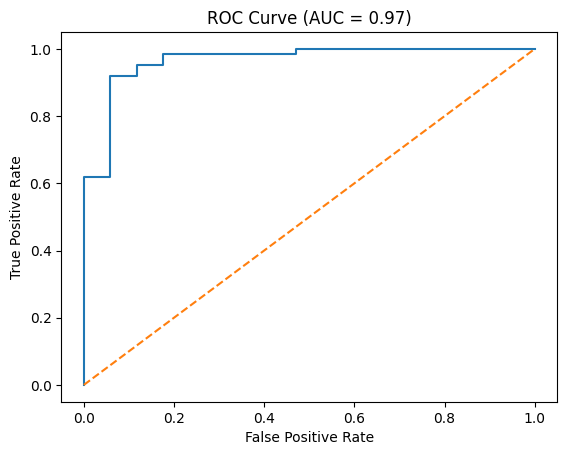

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()